# M4 · Model Families — Hands-on Notebook

**Companion to curriculum lesson M4.** Runnable examples of every model family M4
discusses — **linear / logistic**, **decision trees**, **bagging / random forests**,
**gradient boosting (GBDT)**, and **neural nets (MLP)** — plus the **GBDT-vs-NN
decision**. Runs top-to-bottom in Google Colab with **no installs** (pandas, numpy,
scikit-learn, matplotlib only).

- **Basic (10):** linear reg · logistic reg · the interaction a line misses ·
  feature-cross fix · decision tree + splits · tree solves the interaction ·
  single-tree variance · bagging / random forest · gradient boosting · MLP
- **Easy (5):** GBDT depth sweep · learning-rate ↔ n_trees · tree vs RF vs GBDT
  bake-off · feature importance · extrapolation failure
- **Advanced (5):** entity embeddings for sparse IDs · family bake-off (AUC + cost) ·
  big-MLP-on-tiny-data overfit · calibration across families · decision-boundary gallery

## Setup — two datasets

1. **`df`** — a synthetic **ads** table whose click label has a genuine *interaction*:
   members in the **US** with **bid > 5** click much more. A purely additive linear
   model can't see that combination; trees / GBDT / MLP can.
2. **`X2, y2`** — a clean 2-D **XOR** set (label = one region *or* the other, not both)
   for drawing decision boundaries — the sharpest picture of each family's inductive bias.

In [1]:
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(0)
N = 4000
country = rng.choice(["US","IN","BR","GB","DE","FR","CA","AU"], size=N, p=[.32,.18,.12,.09,.08,.08,.07,.06])
device  = rng.choice(["ios","android","web"], size=N, p=[.45,.40,.15])
size    = rng.choice(["S","M","L"], size=N, p=[.5,.35,.15])
campaign = rng.integers(2000, 2000+300, size=N)          # 300 campaigns (high-card id)
bid     = np.round(rng.uniform(0.5, 12.0, size=N), 2)
spend   = np.round(rng.exponential(40, size=N), 2)

is_US = (country == "US").astype(float)
is_ios = (device == "ios").astype(float)
size_ord = pd.Series({"S":0.,"M":1.,"L":2.})[size].to_numpy()
# four interactions, all computable from the features the models see (FEATS):
inter1 = ((is_US == 1) & (bid > 5)).astype(float)         # US & high bid
inter2 = ((is_ios == 1) & (size_ord == 2)).astype(float)  # iOS & large creative
inter3 = ((size_ord == 0) & (spend > 60)).astype(float)   # small creative & high spend
inter4 = ((is_ios == 0) & (bid < 3)).astype(float)        # non-iOS & low bid
size_lift = pd.Series({"S":0.,"M":.4,"L":.8})[size].to_numpy()
logit = (-2.4 + 2.0*inter1 + 1.7*inter2 + 1.5*inter3 + 1.2*inter4
         + 0.04*bid + 0.003*spend + rng.normal(0, 0.30, N))
clicked = (rng.random(N) < 1/(1+np.exp(-logit))).astype(int)
# a continuous target for the linear-regression demo
value = np.round(5 + 1.2*bid + 0.02*spend + size_lift*2 + rng.normal(0, 2, N), 2)

FEATS = ["is_US", "is_ios", "size_ord", "bid", "spend"]   # tabular features (capture both interactions)
df = pd.DataFrame(dict(country=country, device=device, creative_size=size, campaign_id=campaign,
                       bid=bid, spend=spend, is_US=is_US, is_ios=is_ios, size_ord=size_ord,
                       clicked=clicked, value=value))
train, valid = train_test_split(df, test_size=0.25, random_state=0, stratify=df.clicked)

# 2-D XOR set for decision boundaries
n2 = 1500
x1, x2 = rng.uniform(0,1,n2), rng.uniform(0,1,n2)
y2 = ((x1 > 0.5) ^ (x2 > 0.5)).astype(int)
y2 = np.where(rng.random(n2) < 0.05, 1 - y2, y2)            # 5% label noise
X2 = np.c_[x1, x2]
X2tr, X2va, y2tr, y2va = train_test_split(X2, y2, test_size=0.3, random_state=0)

def plot_boundary(ax, model, title):
    xx, yy = np.meshgrid(np.linspace(0,1,200), np.linspace(0,1,200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=.25, cmap="coolwarm", levels=1)
    ax.scatter(X2va[:,0], X2va[:,1], c=y2va, cmap="coolwarm", s=8, edgecolors="none")
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])

print("df:", df.shape, "| click rate:", round(df.clicked.mean(),3))
print("XOR set:", X2.shape, "| positive rate:", round(y2.mean(),3))
df.head()

df: (4000, 11) | click rate: 0.267
XOR set: (1500, 2) | positive rate: 0.518


---
# Basic (10) — one family / concept per example

## 1 · Linear regression — additive weighted sum (interpretable)

Predicts a **number** as $w_0+\sum_j w_j x_j$. Each coefficient is a clean
"per-unit" effect. Here we predict `value` from `bid` and `spend`.

intercept: 5.42 | coef(bid, spend): [1.22  0.019]


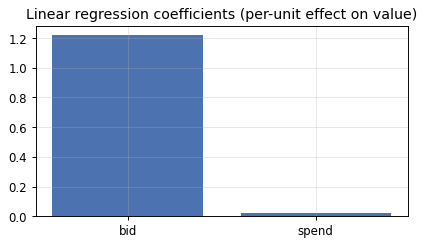

In [2]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression().fit(train[["bid","spend"]], train["value"])
print("intercept:", round(lin.intercept_,2), "| coef(bid, spend):", np.round(lin.coef_,3))

plt.figure(figsize=(5,3))
plt.bar(["bid","spend"], lin.coef_, color=BLUE)
plt.title("Linear regression coefficients (per-unit effect on value)"); plt.show()

## 2 · Logistic regression — score → probability

Wraps the same additive score in a sigmoid to output a **calibrated probability**
for a 0/1 label (pCTR). Coefficients stay interpretable.

val AUC: 0.674 | coefs: {'bid': 0.051, 'spend': 0.007, 'is_US': 1.208, 'is_ios': 0.154, 'size_ord': 0.144}


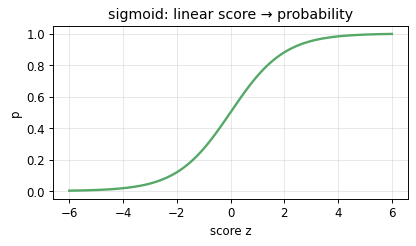

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

feats = ["bid","spend","is_US","is_ios","size_ord"]
lr = LogisticRegression(max_iter=1000).fit(train[feats], train.clicked)
auc = roc_auc_score(valid.clicked, lr.predict_proba(valid[feats])[:,1])
print("val AUC:", round(auc,3), "| coefs:", dict(zip(feats, np.round(lr.coef_[0],3))))

z = np.linspace(-6,6,200)
plt.figure(figsize=(5,3))
plt.plot(z, 1/(1+np.exp(-z)), color=GREEN, lw=2)
plt.title("sigmoid: linear score → probability"); plt.xlabel("score z"); plt.ylabel("p"); plt.show()

## 3 · The interaction a line misses

Clicks jump only when **US *and* bid > 5** — a combination. A logistic model given
`country` and `bid` *separately* can't represent it. The 4-case truth table is XOR-like.

country  bid click_prone
     US    3          no
     US    7         yes
     IN    3          no
     IN    7          no
additive logistic (is_US + bid) val AUC: 0.635


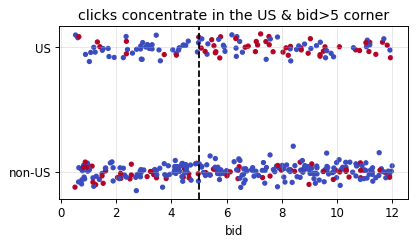

In [4]:
truth = pd.DataFrame({"country":["US","US","IN","IN"], "bid":[3,7,3,7], "click_prone":["no","yes","no","no"]})
print(truth.to_string(index=False))

# logistic with only additive is_US and bid -> can't isolate the US&bid>5 cell
add = LogisticRegression(max_iter=1000).fit(train[["is_US","bid"]], train.clicked)
auc_add = roc_auc_score(valid.clicked, add.predict_proba(valid[["is_US","bid"]])[:,1])
print("additive logistic (is_US + bid) val AUC:", round(auc_add,3))

plt.figure(figsize=(5,3))
sub = valid.sample(400, random_state=1)
plt.scatter(sub.bid, sub.is_US + rng.normal(0,0.05,len(sub)), c=sub.clicked, cmap="coolwarm", s=12)
plt.axvline(5, color="k", ls="--"); plt.yticks([0,1], ["non-US","US"]); plt.xlabel("bid")
plt.title("clicks concentrate in the US & bid>5 corner"); plt.show()

## 4 · Feature cross fixes the linear model

Hand the linear model the interaction as one column (`US_and_bid_gt_5`) and it can
represent the combination — AUC jumps.

additive AUC 0.635  ->  with cross 0.670


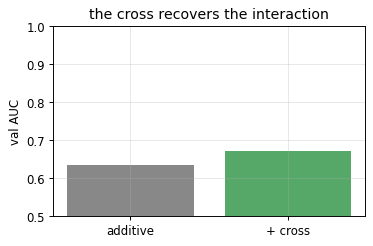

In [5]:
for d in (train, valid):
    d["US_and_bid_gt_5"] = ((d.is_US==1) & (d.bid>5)).astype(int)

feats2 = ["is_US","bid","US_and_bid_gt_5"]
crossed = LogisticRegression(max_iter=1000).fit(train[feats2], train.clicked)
auc_cross = roc_auc_score(valid.clicked, crossed.predict_proba(valid[feats2])[:,1])
print(f"additive AUC {auc_add:.3f}  ->  with cross {auc_cross:.3f}")

plt.figure(figsize=(4.5,3))
plt.bar(["additive","+ cross"], [auc_add, auc_cross], color=[GRAY, GREEN])
plt.ylim(0.5,1.0); plt.ylabel("val AUC"); plt.title("the cross recovers the interaction"); plt.show()

## 5 · Decision tree — threshold splits (reads the interaction directly)

A tree splits on `bid > 5`, then on `country == US`, landing the click-prone case in
its own leaf — no hand-crafted cross needed.

tree val AUC: 0.709


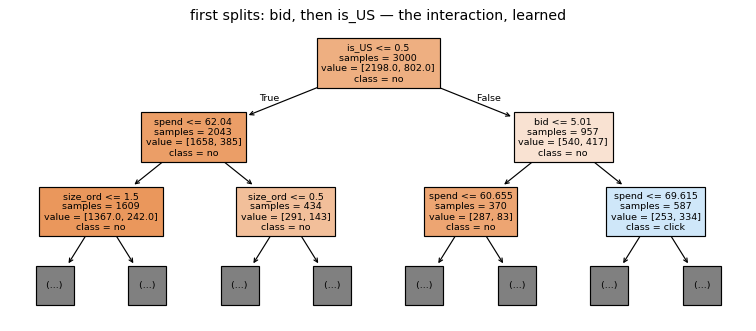

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(train[FEATS], train.clicked)
auc_tree = roc_auc_score(valid.clicked, tree.predict_proba(valid[FEATS])[:,1])
print("tree val AUC:", round(auc_tree,3))

plt.figure(figsize=(9,4))
plot_tree(tree, feature_names=FEATS, class_names=["no","click"],
          filled=True, impurity=False, fontsize=8, max_depth=2)
plt.title("first splits: bid, then is_US — the interaction, learned"); plt.show()

## 6 · Tree vs line on XOR — the boundary picture

On the 2-D XOR set, a linear boundary is one diagonal (≈ chance); a tree carves
axis-aligned boxes that solve it.

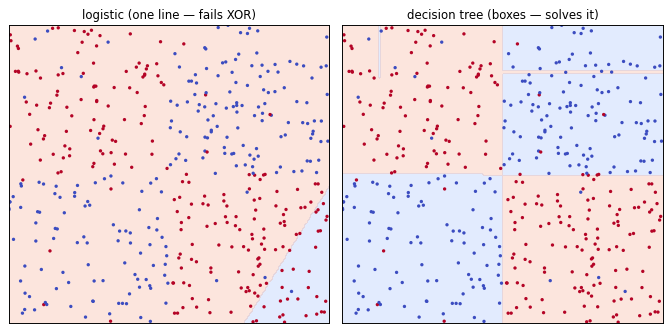

In [7]:
from sklearn.tree import DecisionTreeClassifier

fig, ax = plt.subplots(1, 2, figsize=(8,4))
plot_boundary(ax[0], LogisticRegression().fit(X2tr, y2tr), "logistic (one line — fails XOR)")
plot_boundary(ax[1], DecisionTreeClassifier(max_depth=4, random_state=0).fit(X2tr, y2tr), "decision tree (boxes — solves it)")
plt.show()

## 7 · A single tree is high-variance

Refit a deep tree on two bootstrap resamples: the boundaries differ noticeably —
small data changes swing the splits. Motivates ensembles.

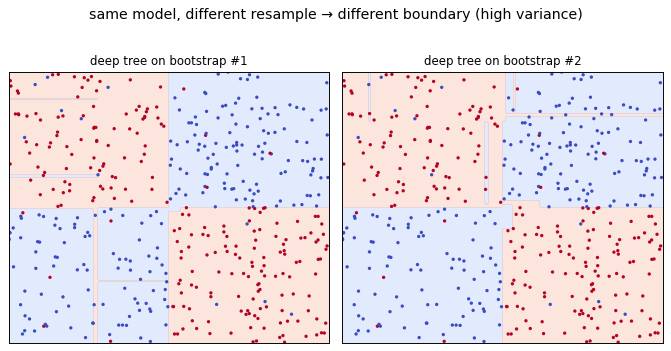

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))
for a, seed in zip(ax, [1, 2]):
    idx = np.random.default_rng(seed).integers(0, len(X2tr), len(X2tr))
    t = DecisionTreeClassifier(max_depth=6, random_state=0).fit(X2tr[idx], y2tr[idx])
    plot_boundary(a, t, f"deep tree on bootstrap #{seed}")
plt.suptitle("same model, different resample → different boundary (high variance)", y=1.02); plt.show()

## 8 · Bagging / Random Forest — average away the variance

Many trees on resampled data + random feature subsets, averaged. The boundary
smooths and validation AUC becomes higher and more stable than one tree.

XOR val AUC — single tree: 0.922 | random forest: 0.95


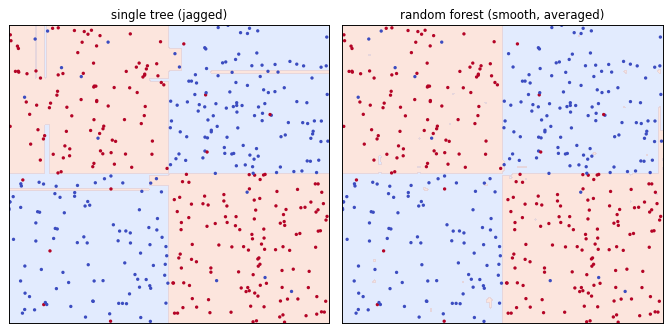

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(X2tr, y2tr)
one = DecisionTreeClassifier(max_depth=6, random_state=0).fit(X2tr, y2tr)
print("XOR val AUC — single tree:", round(roc_auc_score(y2va, one.predict_proba(X2va)[:,1]),3),
      "| random forest:", round(roc_auc_score(y2va, rf.predict_proba(X2va)[:,1]),3))

fig, ax = plt.subplots(1, 2, figsize=(8,4))
plot_boundary(ax[0], one, "single tree (jagged)")
plot_boundary(ax[1], rf, "random forest (smooth, averaged)")
plt.show()

## 9 · Gradient boosting (GBDT) — sequential corrections

Boosting adds shallow trees one at a time, each fitting the current errors. Watch
validation AUC climb as trees accumulate on the ads data.

final GBDT val AUC: 0.74


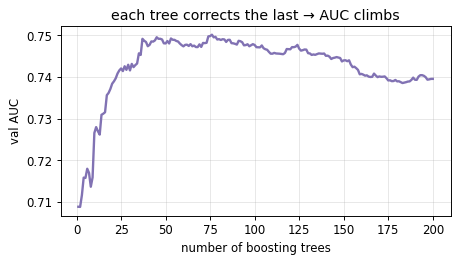

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

feats = FEATS
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=0)
gb.fit(train[feats], train.clicked)
staged = [roc_auc_score(valid.clicked, p[:,1]) for p in gb.staged_predict_proba(valid[feats])]
print("final GBDT val AUC:", round(staged[-1],3))

plt.figure(figsize=(5.5,3.2))
plt.plot(range(1, len(staged)+1), staged, color=PURPLE, lw=2)
plt.xlabel("number of boosting trees"); plt.ylabel("val AUC")
plt.title("each tree corrects the last → AUC climbs"); plt.show()

## 10 · MLP (neural net) — learned nonlinear boundary

A small multilayer perceptron learns a smooth curved boundary on XOR — no
hand-crafted features, at the cost of more tuning.

XOR val AUC — MLP: 0.95


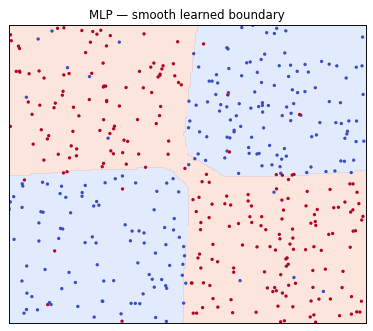

In [11]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(16,16), max_iter=800, random_state=0).fit(X2tr, y2tr)
print("XOR val AUC — MLP:", round(roc_auc_score(y2va, mlp.predict_proba(X2va)[:,1]),3))
fig, ax = plt.subplots(figsize=(4.5,4))
plot_boundary(ax, mlp, "MLP — smooth learned boundary")
plt.show()

---
# Easy (5) — tune & compare

## 11 · GBDT depth sweep — under- vs over-fitting

Depth controls interaction complexity per tree. Shallow underfits; too deep
memorizes — train AUC keeps rising while validation stalls or drops.

 depth  train_AUC  val_AUC
     1      0.724    0.685
     2      0.809    0.744
     3      0.866    0.740
     5      0.972    0.714
     8      1.000    0.686


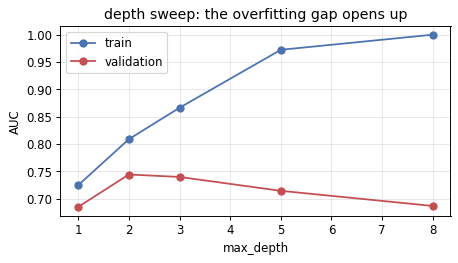

In [12]:
feats = FEATS
rows = []
for depth in [1, 2, 3, 5, 8]:
    m = GradientBoostingClassifier(n_estimators=200, max_depth=depth, learning_rate=0.1, random_state=0).fit(train[feats], train.clicked)
    rows.append((depth, roc_auc_score(train.clicked, m.predict_proba(train[feats])[:,1]),
                        roc_auc_score(valid.clicked, m.predict_proba(valid[feats])[:,1])))
tbl = pd.DataFrame(rows, columns=["depth","train_AUC","val_AUC"]); print(tbl.round(3).to_string(index=False))
plt.figure(figsize=(5.5,3.2))
plt.plot(tbl.depth, tbl.train_AUC, "o-", color=BLUE, label="train")
plt.plot(tbl.depth, tbl.val_AUC, "o-", color=RED, label="validation")
plt.xlabel("max_depth"); plt.ylabel("AUC"); plt.legend(); plt.title("depth sweep: the overfitting gap opens up"); plt.show()

## 12 · Learning rate ↔ number of trees

A smaller learning rate makes each correction tinier — it needs *more* trees but
usually gives a smoother, higher validation curve.

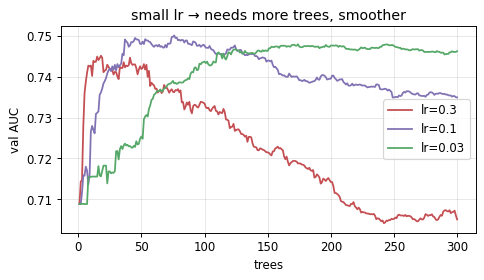

In [13]:
feats = FEATS
plt.figure(figsize=(5.8,3.4))
for lr, c in [(0.3, RED), (0.1, PURPLE), (0.03, GREEN)]:
    m = GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=lr, random_state=0).fit(train[feats], train.clicked)
    staged = [roc_auc_score(valid.clicked, p[:,1]) for p in m.staged_predict_proba(valid[feats])]
    plt.plot(range(1,301), staged, color=c, label=f"lr={lr}")
plt.xlabel("trees"); plt.ylabel("val AUC"); plt.legend(); plt.title("small lr → needs more trees, smoother"); plt.show()

## 13 · Single tree vs Random Forest vs GBDT — bake-off

Same tabular task, three tree-based options: averaging (RF) and boosting (GBDT)
both beat a lone tree.

{'single tree': 0.599, 'random forest': 0.702, 'GBDT': 0.74}


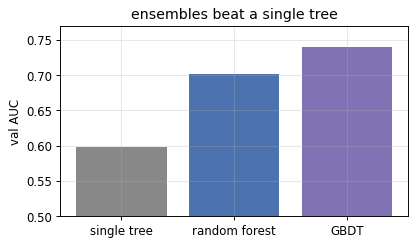

In [14]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
feats = FEATS
res = {
  "single tree": DecisionTreeClassifier(random_state=0),   # full depth → overfits noise
  "random forest": RandomForestClassifier(n_estimators=300, random_state=0),
  "GBDT": GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=0),
}
aucs = {k: roc_auc_score(valid.clicked, v.fit(train[feats], train.clicked).predict_proba(valid[feats])[:,1]) for k,v in res.items()}
print({k: round(v,3) for k,v in aucs.items()})
plt.figure(figsize=(5,3)); plt.bar(list(aucs), list(aucs.values()), color=[GRAY,BLUE,PURPLE])
plt.ylim(0.5, max(aucs.values())+0.03); plt.ylabel("val AUC"); plt.title("ensembles beat a single tree"); plt.show()

## 14 · Feature importance — a peek at interpretability

GBDT reports how much each feature reduced loss. The engineered interaction and
`bid` dominate — matching how we built the data.

is_US              0.005
size_ord           0.085
is_ios             0.087
bid                0.205
spend              0.298
US_and_bid_gt_5    0.320
dtype: float64


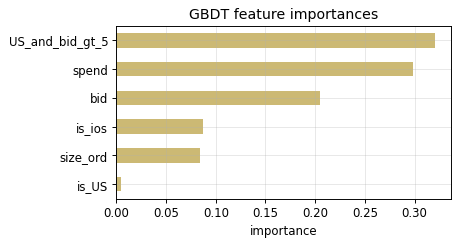

In [15]:
feats = FEATS + ["US_and_bid_gt_5"]
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=0).fit(train[feats], train.clicked)
imp = pd.Series(gb.feature_importances_, index=feats).sort_values()
print(imp.round(3))
plt.figure(figsize=(5.5,3)); imp.plot(kind="barh", color=GOLD)
plt.title("GBDT feature importances"); plt.xlabel("importance"); plt.show()

## 15 · Extrapolation — trees go flat, lines don't

Trees predict from leaf regions, so beyond the training range they output a
**constant**; a linear model keeps trending. Fit on x∈[0,5], predict to x=8.

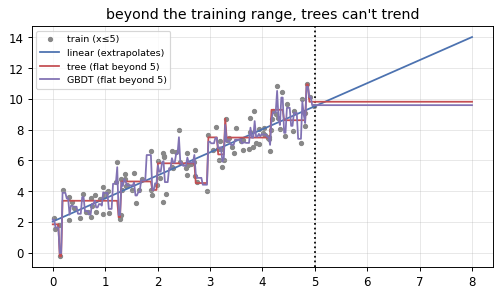

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
xr = np.sort(np.random.default_rng(1).uniform(0,5,120))
yr = 2 + 1.5*xr + np.random.default_rng(2).normal(0,1,120)
Xr = xr[:,None]; grid = np.linspace(0,8,300)[:,None]
lin = LinearRegression().fit(Xr, yr)
tre = DecisionTreeRegressor(max_depth=4, random_state=0).fit(Xr, yr)
gbr = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=0).fit(Xr, yr)
plt.figure(figsize=(6,3.6))
plt.scatter(xr, yr, s=12, color=GRAY, label="train (x≤5)")
plt.axvline(5, color="k", ls=":")
plt.plot(grid, lin.predict(grid), color=BLUE, label="linear (extrapolates)")
plt.plot(grid, tre.predict(grid), color=RED, label="tree (flat beyond 5)")
plt.plot(grid, gbr.predict(grid), color=PURPLE, label="GBDT (flat beyond 5)")
plt.legend(fontsize=8); plt.title("beyond the training range, trees can't trend"); plt.show()

---
# Advanced (5)

## 16 · Entity embeddings for a high-cardinality id

One-hot `campaign_id` (300 sparse columns) vs a learned **dense** vector. Deep models
use `torch.nn.Embedding`; here a runnable stand-in (truncated SVD of a campaign×context
matrix) gives each campaign a 2-D coordinate — similar campaigns cluster.

one-hot columns: 314 -> dense embedding dims: 2


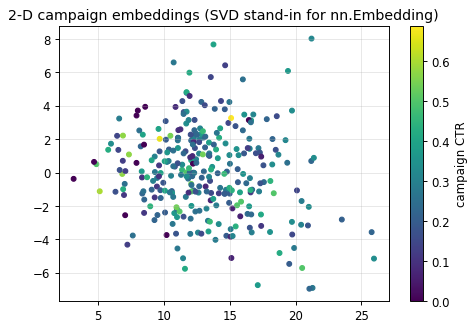

In [17]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder

ctx = OneHotEncoder(sparse_output=False).fit_transform(df[["country","device","creative_size"]])
codes, uniq = pd.factorize(df.campaign_id)
agg = np.zeros((len(uniq), ctx.shape[1])); np.add.at(agg, codes, ctx)
emb = TruncatedSVD(n_components=2, random_state=0).fit_transform(agg)
ctr = df.groupby("campaign_id").clicked.mean().reindex(uniq).to_numpy()
print("one-hot columns:", ctx.shape[1]+len(uniq), "-> dense embedding dims:", emb.shape[1])
plt.figure(figsize=(5.5,4))
sc = plt.scatter(emb[:,0], emb[:,1], c=ctr, cmap="viridis", s=16); plt.colorbar(sc, label="campaign CTR")
plt.title("2-D campaign embeddings (SVD stand-in for nn.Embedding)"); plt.show()

## 17 · Family bake-off — AUC vs cost

Train all four families on the same task and compare validation AUC **and** fit time —
the GBDT-vs-NN decision, made concrete.

      family  val_AUC  fit_secs
    logistic    0.674     0.014
randomforest    0.702     0.660
        GBDT    0.740     0.327
         MLP    0.738     0.754


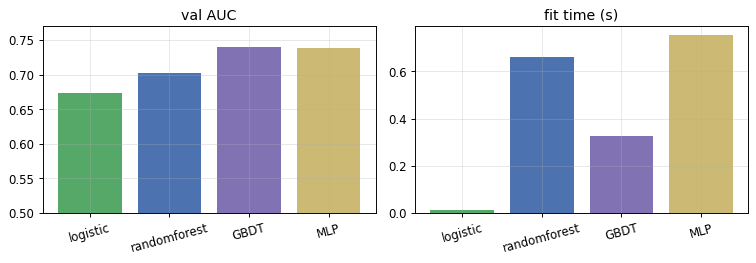

In [18]:
from sklearn.preprocessing import StandardScaler
feats = FEATS
Xtr, Xva = train[feats].to_numpy(), valid[feats].to_numpy()
Xtr_s = StandardScaler().fit(Xtr); Xtr_z, Xva_z = Xtr_s.transform(Xtr), Xtr_s.transform(Xva)
models = {
  "logistic":     (LogisticRegression(max_iter=1000), Xtr_z, Xva_z),
  "randomforest": (RandomForestClassifier(n_estimators=300, random_state=0), Xtr, Xva),
  "GBDT":         (GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=0), Xtr, Xva),
  "MLP":          (MLPClassifier(hidden_layer_sizes=(32,16), max_iter=600, random_state=0), Xtr_z, Xva_z),
}
rows = []
for name,(m,a,b) in models.items():
    t=time.time(); m.fit(a, train.clicked); dt=time.time()-t
    rows.append((name, round(roc_auc_score(valid.clicked, m.predict_proba(b)[:,1]),3), round(dt,3)))
tbl = pd.DataFrame(rows, columns=["family","val_AUC","fit_secs"]); print(tbl.to_string(index=False))
fig, ax = plt.subplots(1,2, figsize=(9,3.2))
ax[0].bar(tbl.family, tbl.val_AUC, color=[GREEN,BLUE,PURPLE,GOLD]); ax[0].set_ylim(0.5, tbl.val_AUC.max()+0.03); ax[0].set_title("val AUC")
ax[1].bar(tbl.family, tbl.fit_secs, color=[GREEN,BLUE,PURPLE,GOLD]); ax[1].set_title("fit time (s)")
for a in ax: a.tick_params(axis="x", rotation=15)
plt.show()

## 18 · Big MLP on tiny data — overfitting

Give a large MLP only 60 rows: it drives train AUC to ~1.0 while validation lags —
too much flexibility for the data. GBDT is steadier on the same tiny sample.

                  model  train_AUC  val_AUC
big MLP (high capacity)      1.000    0.520
logistic (low capacity)      0.622    0.619


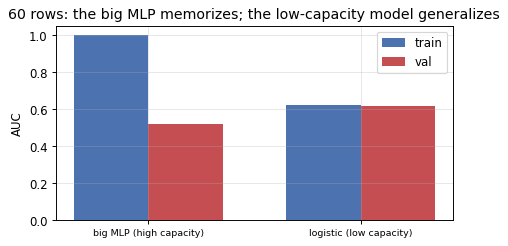

In [19]:
from sklearn.preprocessing import StandardScaler
feats = FEATS
tiny = train.sample(60, random_state=0)
sc = StandardScaler().fit(tiny[feats])
Xt, Xv = sc.transform(tiny[feats]), sc.transform(valid[feats])
big   = MLPClassifier(hidden_layer_sizes=(128,128,64), max_iter=1500, random_state=0).fit(Xt, tiny.clicked)
small = LogisticRegression(max_iter=1000).fit(Xt, tiny.clicked)
rows = [("big MLP (high capacity)", roc_auc_score(tiny.clicked, big.predict_proba(Xt)[:,1]),   roc_auc_score(valid.clicked, big.predict_proba(Xv)[:,1])),
        ("logistic (low capacity)", roc_auc_score(tiny.clicked, small.predict_proba(Xt)[:,1]), roc_auc_score(valid.clicked, small.predict_proba(Xv)[:,1]))]
tbl = pd.DataFrame(rows, columns=["model","train_AUC","val_AUC"]); print(tbl.round(3).to_string(index=False))
x = np.arange(2); w=0.35
plt.figure(figsize=(5.5,3))
plt.bar(x-w/2, tbl.train_AUC, w, color=BLUE, label="train"); plt.bar(x+w/2, tbl.val_AUC, w, color=RED, label="val")
plt.xticks(x, tbl.model, fontsize=8); plt.ylabel("AUC"); plt.legend()
plt.title("60 rows: the big MLP memorizes; the low-capacity model generalizes"); plt.show()

## 19 · Calibration across families

A probability of 0.7 should mean "clicks ~70% of the time." Logistic tends to be
well-calibrated; RF/boosting often need calibration. Reliability curves show it.

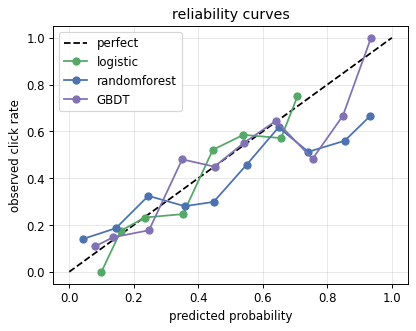

In [20]:
from sklearn.calibration import calibration_curve
feats = FEATS
fitted = {
  "logistic":     LogisticRegression(max_iter=1000).fit(train[feats], train.clicked),
  "randomforest": RandomForestClassifier(n_estimators=300, random_state=0).fit(train[feats], train.clicked),
  "GBDT":         GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=0).fit(train[feats], train.clicked),
}
plt.figure(figsize=(5,4)); plt.plot([0,1],[0,1],"k--",label="perfect")
for (name,m),c in zip(fitted.items(), [GREEN,BLUE,PURPLE]):
    frac, mean = calibration_curve(valid.clicked, m.predict_proba(valid[feats])[:,1], n_bins=10)
    plt.plot(mean, frac, "o-", color=c, label=name)
plt.xlabel("predicted probability"); plt.ylabel("observed click rate"); plt.legend(); plt.title("reliability curves"); plt.show()

## 20 · Decision-boundary gallery — inductive bias at a glance

The same XOR data through five families. Notice: logistic = one line (fails), tree =
boxes, RF/GBDT = smoother boxes, MLP = a smooth curve. This *is* "model family = a bet
about what patterns are easy to learn."

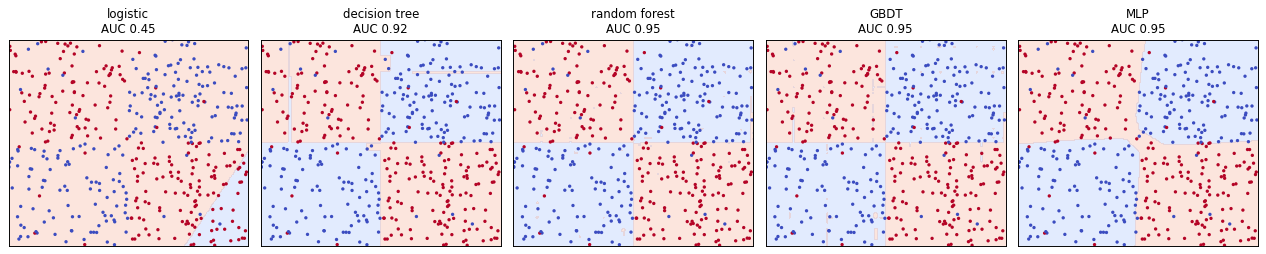

In [21]:
gallery = {
  "logistic":     LogisticRegression().fit(X2tr, y2tr),
  "decision tree":DecisionTreeClassifier(max_depth=5, random_state=0).fit(X2tr, y2tr),
  "random forest":RandomForestClassifier(n_estimators=300, random_state=0).fit(X2tr, y2tr),
  "GBDT":         GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=0).fit(X2tr, y2tr),
  "MLP":          MLPClassifier(hidden_layer_sizes=(16,16), max_iter=800, random_state=0).fit(X2tr, y2tr),
}
fig, ax = plt.subplots(1, 5, figsize=(15,3.1))
for a,(name,m) in zip(ax, gallery.items()):
    plot_boundary(a, m, f"{name}\nAUC {roc_auc_score(y2va, m.predict_proba(X2va)[:,1]):.2f}")
plt.show()

---
## Recap — picking a family

- **Linear / logistic:** additive, interpretable, cheap; needs **feature crosses** for
  interactions. Great calibrated baseline.
- **Single tree:** captures thresholds & interactions automatically, but **high variance**.
- **Random forest (bagging):** averages many trees → variance down, strong & robust.
- **GBDT (boosting):** sequential corrections → usually the **best on tabular**; tune
  depth / learning-rate / n_trees; watch overfitting, weak **extrapolation**.
- **MLP / neural nets:** learn representations; shine on **sparse IDs (embeddings),
  text, sequences, images** and shared tasks; need more data, tuning, and serving care.

Rule of thumb: **medium tabular → start with GBDT**; **sparse/text/sequence or shared
representations → neural net**; always keep a **logistic baseline** for calibration and
interpretability.